In [1]:
import QuantLib as ql

evaluation_date = ql.Date(14, ql.July, 2026)
ql.Settings.instance().evaluationDate = evaluation_date

# Handle

In [2]:
day_count = ql.Actual365Fixed()

rate_quote = ql.SimpleQuote(0.05)
rate_handle = ql.QuoteHandle(rate_quote)

curve = ql.FlatForward(
    evaluation_date,
    rate_handle,
    day_count,
)

In [3]:
maturity = ql.Date(14, ql.July, 2031)

discount_factor = curve.discount(maturity)

zero_continuous = curve.zeroRate(
    maturity,
    ql.Actual365Fixed(),
    ql.Continuous,
    ql.NoFrequency,
).rate()

zero_annual = curve.zeroRate(
    maturity,
    ql.Actual365Fixed(),
    ql.Compounded,
    ql.Annual,
).rate()

forward_1y = curve.forwardRate(
    ql.Date(14, ql.July, 2028),
    ql.Date(14, ql.July, 2029),
    ql.Actual365Fixed(),
    ql.Compounded,
    ql.Annual,
).rate()

In [4]:
print(discount_factor, zero_continuous, zero_annual, forward_1y)

0.7786941053394888 0.04999999999999999 0.05127109637602412 0.051271096376023895


In [5]:
date_5y = ql.Date(14, ql.July, 2031)

df_before = curve.discount(date_5y)

rate_quote.setValue(0.051)

df_after = curve.discount(date_5y)

print(df_before)
print(df_after)

0.7786941053394888
0.7748082295213918


# Moving vs. Fixed

In [6]:
quote = ql.SimpleQuote(0.05)

moving_curve = ql.FlatForward(
    0,
    ql.UnitedStates(ql.UnitedStates.GovernmentBond),
    ql.QuoteHandle(quote),
    ql.Actual365Fixed(),
)

fixed_curve = ql.FlatForward(
    ql.Date(14, ql.July, 2026),
    ql.QuoteHandle(quote),
    ql.Actual365Fixed(),
)

In [28]:
ql.Settings.instance().evaluationDate = ql.Date(14, ql.July, 2026)

print(moving_curve.referenceDate())
print(fixed_curve.referenceDate())

ql.Settings.instance().evaluationDate = ql.Date(15, ql.July, 2026)

print(moving_curve.referenceDate())
print(fixed_curve.referenceDate())

July 14th, 2026
July 14th, 2026
July 15th, 2026
July 14th, 2026


In [26]:
moving_curve.discount(5.0), fixed_curve.discount(5.0)

(0.7788007830714049, 0.7788007830714049)

In [29]:
target_date = ql.Date(14, ql.July, 2031)

moving_curve.discount(target_date), fixed_curve.discount(target_date)

(0.7788007830714049, 0.7786941053394888)

# DiscountCurve vs. ZeroCurve

In [9]:
import math
import QuantLib as ql
import pandas as pd
import numpy as np

evaluation_date = ql.Date(14, ql.July, 2026)
ql.Settings.instance().evaluationDate = evaluation_date

calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
curve_day_count = ql.Actual365Fixed()

node_dates = [
    evaluation_date,
    calendar.advance(evaluation_date, ql.Period(1, ql.Years)),
    calendar.advance(evaluation_date, ql.Period(2, ql.Years)),
    calendar.advance(evaluation_date, ql.Period(5, ql.Years)),
    calendar.advance(evaluation_date, ql.Period(10, ql.Years)),
]

zero_nodes = [
    0.0400,
    0.0430,
    0.0450,
    0.0420,
    0.0400,
]

In [10]:
node_times = [
    curve_day_count.yearFraction(evaluation_date, d)
    for d in node_dates
]

discount_nodes = [
    math.exp(-z * t)
    for z, t in zip(zero_nodes, node_times)
]

node_table = pd.DataFrame(
    {
        "date": node_dates,
        "time": node_times,
        "zero_continuous": zero_nodes,
        "discount_factor": discount_nodes,
    }
)

node_table

,date,time,zero_continuous,discount_factor
0,"July 14th, 2026",0.000000,0.040,1.000000
1,"July 14th, 2027",1.000000,0.043,0.957911
2,"July 14th, 2028",2.002740,0.045,0.913819
3,"July 14th, 2031",5.002740,0.042,0.810491
4,"July 14th, 2036",10.008219,0.040,0.670100


In [11]:
flat_quote = ql.SimpleQuote(0.0420)

flat_curve = ql.FlatForward(
    evaluation_date,
    ql.QuoteHandle(flat_quote),
    curve_day_count,
    ql.Continuous,
    ql.NoFrequency,
)

In [ ]:
date_5y = calendar.advance(
    evaluation_date,
    ql.Period(5, ql.Years)
)

df_before = flat_curve.discount(date_5y)

flat_quote.setValue(0.0430)

df_after = flat_curve.discount(date_5y)

print(df_before)
print(df_after)
flat_quote.setValue(0.0420)

0.8104909786286008
0.8064464285632508


In [ ]:
discount_curve = ql.DiscountCurve(
    node_dates,
    discount_nodes,
    curve_day_count,
    calendar,
)

zero_curve = ql.ZeroCurve(
    node_dates,
    zero_nodes,
    curve_day_count,
    calendar,
    ql.Linear(),
    ql.Continuous,
    ql.Annual,
)

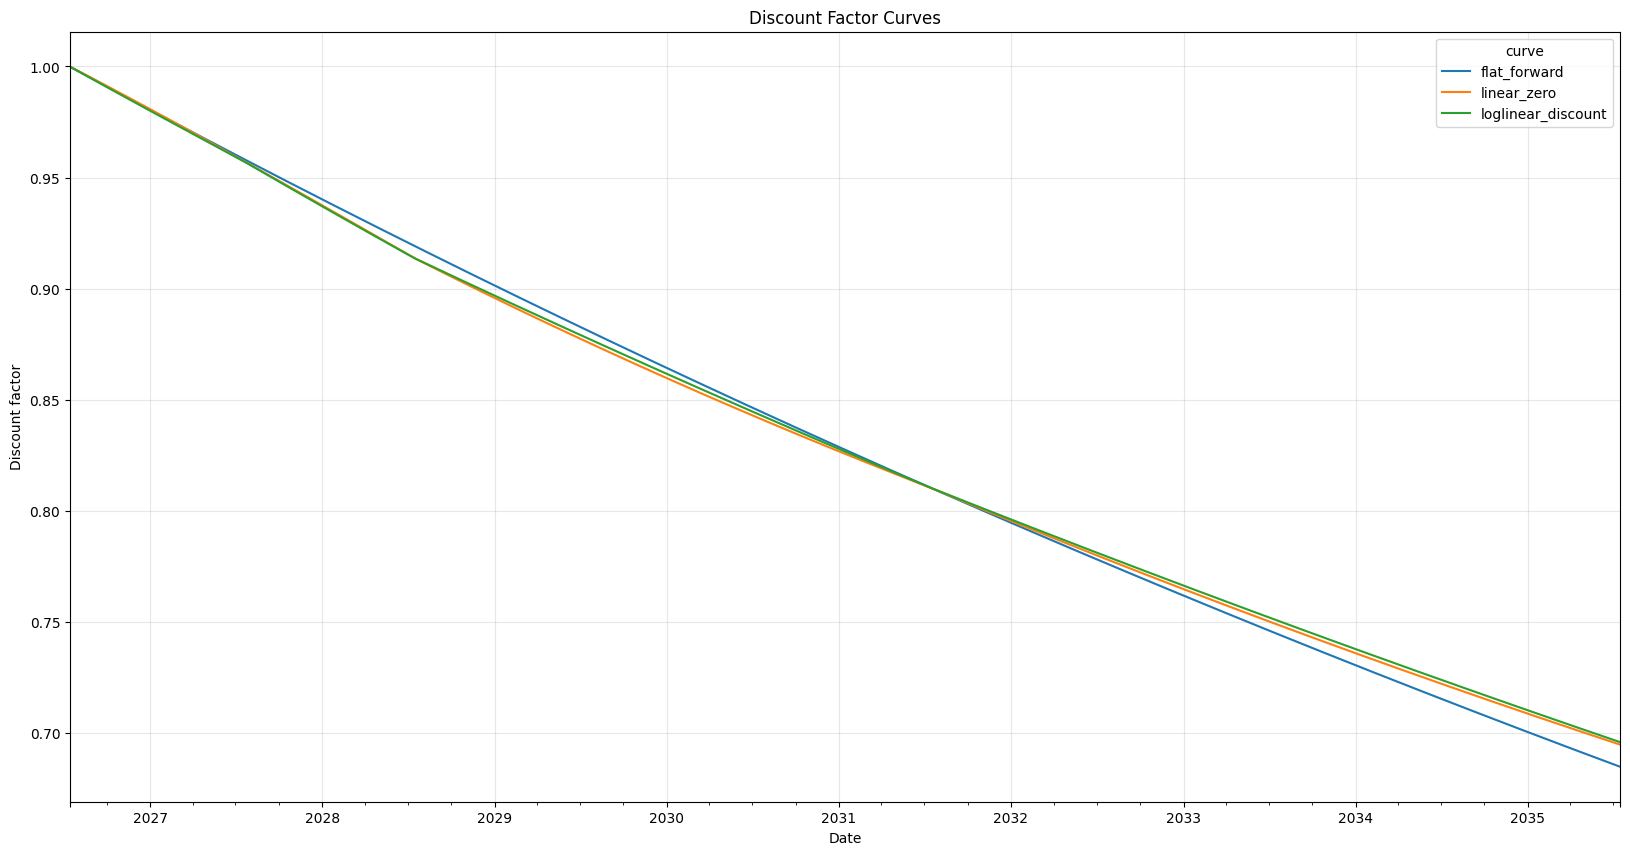

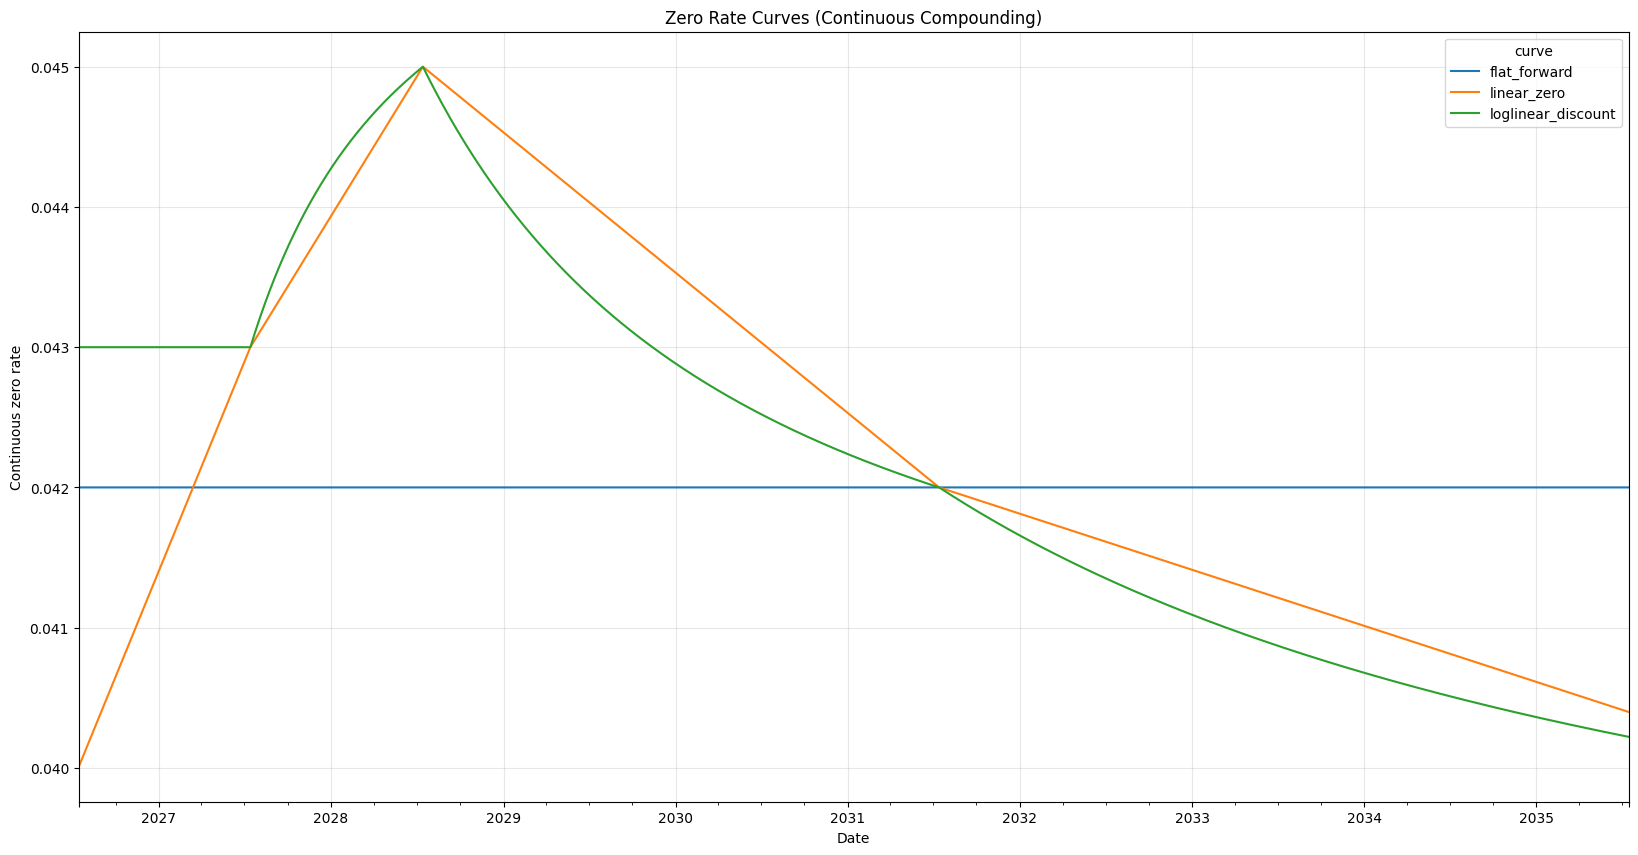

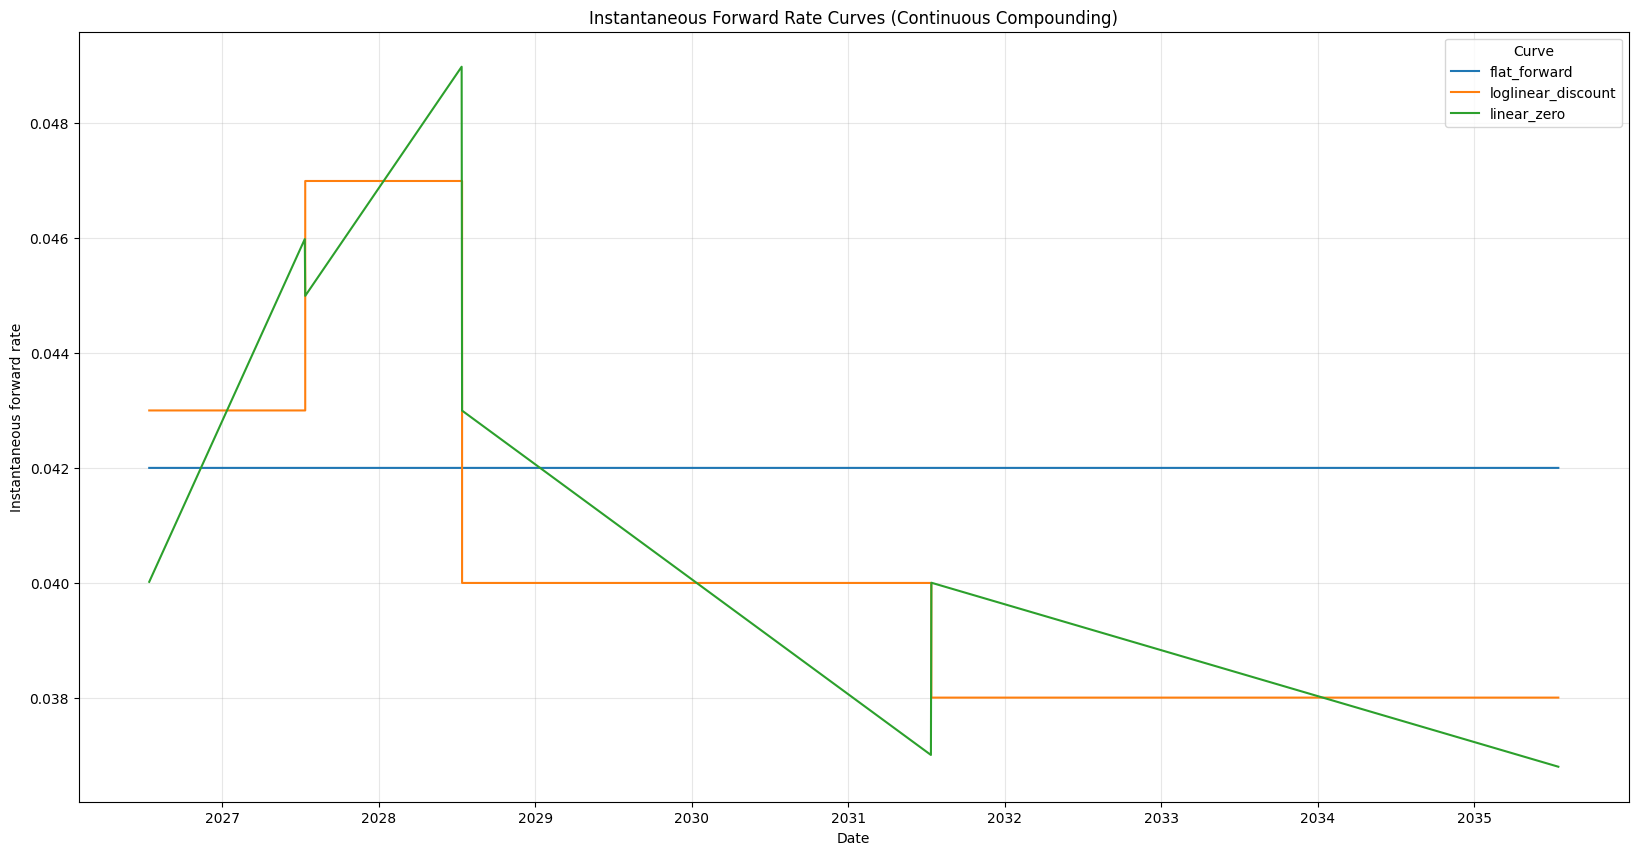

In [31]:
import pandas as pd
import matplotlib.pyplot as plt


def ql_date_to_timestamp(date):
    """QuantLib Date -> pandas Timestamp."""
    return pd.Timestamp(
        year=date.year(),
        month=date.month(),
        day=date.dayOfMonth(),
    )


def right_instantaneous_forward(
    curve,
    date,
    epsilon=1.0e-5,
):
    """
    计算右侧瞬时连续复利远期。

    使用 [t, t + epsilon]，而不是 forwardRate(date, date)，
    可以避免恰好位于 pillar 时左右两侧有限差分混合的问题。
    """
    t = curve.timeFromReference(date)
    max_t = curve.maxTime()

    if t + epsilon <= max_t:
        return curve.forwardRate(
            t,
            t + epsilon,
            ql.Continuous,
            ql.NoFrequency,
        ).rate()

    # 接近曲线末端时改用左侧区间
    t1 = max(0.0, t - epsilon)

    return curve.forwardRate(
        t1,
        t,
        ql.Continuous,
        ql.NoFrequency,
    ).rate()


def query_curve(
    curve,
    dates,
    forward_tenor=ql.Period(3, ql.Months),
    forward_day_count=None,
):
    rows = []

    # 对 zero curve 的插值形状，应使用曲线自身的时间尺度
    curve_day_count = curve.dayCounter()

    # 3M 市场远期可以单独指定 day count
    if forward_day_count is None:
        forward_day_count = curve_day_count

    for date in dates:
        forward_end = calendar.advance(
            date,
            forward_tenor,
            ql.ModifiedFollowing,
        )

        discount = curve.discount(date)

        zero_continuous = curve.zeroRate(
            date,
            curve_day_count,
            ql.Continuous,
            ql.NoFrequency,
        ).rate()

        zero_annual = curve.zeroRate(
            date,
            curve_day_count,
            ql.Compounded,
            ql.Annual,
        ).rate()

        # 用于观察插值器所隐含的 forward 形状
        forward_instantaneous = right_instantaneous_forward(
            curve,
            date,
        )

        # 保留原来的 rolling 3M simple forward，作为另一种指标
        forward_3m_simple = curve.forwardRate(
            date,
            forward_end,
            forward_day_count,
            ql.Simple,
            ql.NoFrequency,
        ).rate()

        rows.append(
            {
                "date": ql_date_to_timestamp(date),
                "discount_factor": discount,
                "zero_continuous": zero_continuous,
                "zero_annual": zero_annual,
                "forward_instantaneous_continuous": forward_instantaneous,
                "forward_3m_simple": forward_3m_simple,
            }
        )

    return pd.DataFrame(rows)


requested_end_date = calendar.advance(
    evaluation_date,
    ql.Period(9, ql.Years),
    ql.ModifiedFollowing,
)

# 避免查询到任何一条曲线的定义域之外
start_date = max(
    [
        evaluation_date,
        flat_curve.referenceDate(),
        discount_curve.referenceDate(),
        zero_curve.referenceDate(),
    ],
    key=lambda d: d.serialNumber(),
)

end_date = min(
    [
        requested_end_date,
        flat_curve.maxDate(),
        discount_curve.maxDate(),
        zero_curve.maxDate(),
    ],
    key=lambda d: d.serialNumber(),
)

number_of_days = end_date - start_date

query_dates = [
    start_date + day
    for day in range(1, number_of_days + 1)
]

flat_result = query_curve(
    flat_curve,
    query_dates,
)

discount_result = query_curve(
    discount_curve,
    query_dates,
)

zero_result = query_curve(
    zero_curve,
    query_dates,
)

flat_result["curve"] = "flat_forward"
discount_result["curve"] = "loglinear_discount"
zero_result["curve"] = "linear_zero"

curve_results = pd.concat(
    [
        flat_result,
        discount_result,
        zero_result,
    ],
    ignore_index=True,
)

discount_pivot = curve_results.pivot(
    index="date",
    columns="curve",
    values="discount_factor",
)

ax = discount_pivot.plot(
    figsize=(20, 10),
    title="Discount Factor Curves",
)

ax.set_xlabel("Date")
ax.set_ylabel("Discount factor")
ax.grid(True, alpha=0.3)

plt.show()

zero_pivot = curve_results.pivot(
    index="date",
    columns="curve",
    values="zero_continuous",
)

ax = zero_pivot.plot(
    figsize=(20, 10),
    title="Zero Rate Curves (Continuous Compounding)",
)

ax.set_xlabel("Date")
ax.set_ylabel("Continuous zero rate")
ax.grid(True, alpha=0.3)

plt.show()

fig, ax = plt.subplots(figsize=(20, 10))

curve_order = [
    "flat_forward",
    "loglinear_discount",
    "linear_zero",
]

step_curves = {
    "flat_forward",
    "loglinear_discount",
}

for curve_name in curve_order:
    data = (
        curve_results[
            curve_results["curve"] == curve_name
        ]
        .sort_values("date")
    )

    x = data["date"]
    y = data["forward_instantaneous_continuous"]

    if curve_name in step_curves:
        ax.step(
            x,
            y,
            where="post",
            label=curve_name,
        )
    else:
        ax.plot(
            x,
            y,
            label=curve_name,
        )

ax.set_title(
    "Instantaneous Forward Rate Curves "
    "(Continuous Compounding)"
)
ax.set_xlabel("Date")
ax.set_ylabel("Instantaneous forward rate")
ax.legend(title="Curve")
ax.grid(True, alpha=0.3)

plt.show()

# Relinkable Handle

In [38]:
reference_date = ql.Date(14, ql.July, 2026)
ql.Settings.instance().evaluationDate = reference_date

base_curve = ql.FlatForward(
    reference_date,
    0.04,
    ql.Actual365Fixed(),
    ql.Continuous,
    ql.NoFrequency,
)

stress_curve = ql.FlatForward(
    reference_date,
    0.05,
    ql.Actual365Fixed(),
    ql.Continuous,
    ql.NoFrequency,
)

curve_handle = ql.RelinkableYieldTermStructureHandle()

In [39]:
maturity_date = ql.Date(14, ql.July, 2031)

bond = ql.ZeroCouponBond(
    settlementDays=0,
    calendar=calendar,
    faceAmount=100.0,
    maturityDate=maturity_date,
)

engine = ql.DiscountingBondEngine(curve_handle)
bond.setPricingEngine(engine)

In [40]:
curve_handle.linkTo(base_curve)
base_npv = bond.NPV()

curve_handle.linkTo(stress_curve)
stress_npv = bond.NPV()

In [41]:
base_npv, stress_npv

(81.86410340760358, 77.86941053394888)